**Sector-Based Portfolio Optimization and Benchmark Comparison - Communication Services**

Silvia Barnes

In [ ]:
current_price = info.get("currentPrice")
target_mean   = info.get("targetMeanPrice")
expected_return = (target_mean - current_price) / current_price

This produces a vector of expected returns:
$$\mu = (\mu_1, \mu_2, \ldots, \mu_n)$$

**Covariance Matrix of Returns**

We compute the covariance matrix using the daily percent returns: cov_matrix = returns.cov()

This covariance captures:
- Individual asset volatility  
- Correlation between assets  

**Portfolio Variance Formula**

For a portfolio with weight vector $w$:

$$\sigma_p^2 = w^T \Sigma w$$

The diversification effect comes from the cross-terms:

$$2 w_i w_j \rho_{ij} \sigma_i \sigma_j$$

Where:
- $ \rho_{ij} $ is the correlation between assets  
- Negative correlation reduces portfolio risk  
- Positive correlation increases portfolio risk  

**Optimization Method: Maximizing the Sharpe Ratio**

We use the SLSQP (Sequential Least Squares Programming) optimization method to maximize:

$$\text{Sharpe}(w) = \frac{w^T \mu - r_f}{\sqrt{w^T\Sigma w}}$$

Since optimizers minimize functions, we minimize:

$$\text{Sharpe}(w)$$

In [ ]:
def portfolio_stats(weights, mean_returns, cov_matrix, rf=0):
    port_return = np.dot(weights, mean_returns)
    port_vol    = np.sqrt(weights.T @ cov_matrix.values @ weights)
    sharpe      = (port_return - rf) / port_vol
    return port_return, port_vol, sharpe

def neg_sharpe(weights):
    return -portfolio_stats(weights, expected_returns, cov_matrix, rf)

**Constraints**

**1. Full Investment Constraint**

$$\sum_i w_i = 1$$

**2. Long-Only Constraint**: this implies:

- No shorting → weights must be ≥ 0
- Optimizer tends to concentrate weight in top expected-return assets
- Low-return or highly correlated assets get zero weight

$$w_i \ge 0$$

In [ ]:
# implemented as:

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = tuple((0, 1) for _ in range(num_assets))

**Optimization Execution (SLSQP)**

In [ ]:
# solve:

opt = sco.minimize(
    neg_sharpe,
    initial_guess,
    method = 'SLSQP',
    bounds = bounds,
    constraints = constraints
)

**Results**

In [19]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
pip install yfinance

In [13]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as sco


# load S&P 500 tickers

url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
sp500 = pd.read_csv(url)

# filter Communication Services stocks

sector_df = sp500[sp500["GICS Sector"] == "Communication Services"]
tickers = sector_df["Symbol"].tolist()

print("Communication Services tickers:")
display(sector_df[["Symbol", "Security"]])

Communication Services tickers:


,Symbol,Security
19,GOOGL,Alphabet Inc. (Class A)
20,GOOG,Alphabet Inc. (Class C)
46,T,AT&T
98,CHTR,Charter Communications
116,CMCSA,Comcast
165,EA,Electronic Arts
202,FOXA,Fox Corporation (Class A)
203,FOX,Fox Corporation (Class B)
253,IPG,Interpublic Group of Companies (The)
289,LYV,Live Nation Entertainment


In [20]:
# download price data
raw = yf.download(tickers, start="2020-01-01")

if isinstance(raw.columns, pd.MultiIndex):
    
    # try common price fields in order
    possible_fields = ["Adj Close", "Adjusted Close", "Close"]
    
    for field in possible_fields:
        if field in raw.columns.get_level_values(0):
            data = raw[field]
            print(f"Using price field: {field}")
            break
    else:
        raise KeyError("None of the expected price fields ('Adj Close', 'Adjusted Close', 'Close') were found.")
else:
    print("Single-index price format detected → using raw data directly.")
    data = raw


# remove columns with all-NaN data
data = data.dropna(axis=1, how="all")

print("Price Data Shape:", data.shape)

# compute daily returns
returns = data.pct_change().dropna()
print("Returns Shape:", returns.shape)

# compute expected returns (analyst targets)
expected_returns = {}

print("Collecting analyst data...")
for t in data.columns:
    info = yf.Ticker(t).info
    current = info.get("currentPrice")
    target = info.get("targetMeanPrice")

    if current and target:
        expected_returns[t] = (target - current) / current

# convert dict to vector
expected_returns = pd.Series(expected_returns)

# align with available tickers
expected_returns = expected_returns.reindex(data.columns)

# drop tickers missing expected returns
expected_returns = expected_returns.dropna()

print("\nExpected Returns:")
print(expected_returns)
print()

# filter returns & prices to match expected returns tickers
usable = expected_returns.index
returns = returns[usable]

# Annualize covariance

cov_matrix = returns.cov() * 252  # annualized covariance
annual_returns = expected_returns # already annual from analyst targets

print("Usable tickers for optimization:")
print(list(usable))
print()

# updated portfolio statistics function

def portfolio_stats(weights, mean_returns, cov_matrix, rf=0):
    port_return = np.dot(weights, mean_returns)        # annual expected return
    port_vol = np.sqrt(weights.T @ cov_matrix.values @ weights)   # annual volatility
    sharpe = (port_return - rf) / port_vol
    return port_return, port_vol, sharpe

# update negative Sharpe to use annual_returns

def neg_sharpe(weights):
    return -portfolio_stats(weights, annual_returns.values, cov_matrix)[2]

# constraints & bounds
num_assets = len(usable)
initial_guess = np.ones(num_assets) / num_assets

constraints = ({'type':'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))

# optimize portfolio
print("Running optimization...")
result = sco.minimize(
    neg_sharpe,
    initial_guess,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={'disp': True}
)

if not result.success:
    print("Optimization failed:", result.message)
else:
    print("Optimization succeeded.\n")

# output final weights
weights = pd.Series(result.x, index=usable)

print("Final portfolio weights:")
print(weights)
print("\nWeights sum to:", weights.sum())

# performance metrics
port_return, port_vol, sharpe = portfolio_stats(weights, annual_returns.values, cov_matrix)

print("\nPerformance Metrics")
print("----------------------")
print(f"Expected Return:   {port_return:.4f}")
print(f"Volatility:        {port_vol:.4f}")
print(f"Sharpe Ratio:      {sharpe:.4f}")

[*********************100%***********************]  24 of 24 completed


Using price field: Close
Price Data Shape: (1487, 24)
Returns Shape: (1486, 24)

Expected Returns:
Ticker
CHTR     0.578020
CMCSA    0.298146
DIS      0.243173
EA       0.000731
FOXA     0.072593
GOOG    -0.019833
GOOGL    0.019650
IPG      0.334380
LYV      0.281579
META     0.308507
MTCH     0.112742
NFLX     0.239443
NWS     -0.013605
NWSA     0.421101
OMC      0.381258
PSKY    -0.085009
T        0.193318
TKO      0.148523
TMUS     0.331099
TTD      0.564592
TTWO     0.120751
VZ       0.164686
WBD     -0.063901
dtype: float64

Usable tickers for optimization:
['CHTR', 'CMCSA', 'DIS', 'EA', 'FOXA', 'GOOG', 'GOOGL', 'IPG', 'LYV', 'META', 'MTCH', 'NFLX', 'NWS', 'NWSA', 'OMC', 'PSKY', 'T', 'TKO', 'TMUS', 'TTD', 'TTWO', 'VZ', 'WBD']

Running optimization...
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.8902507459202347
            Iterations: 9
            Function evaluations: 218
            Gradient evaluations: 9
Optimization succeeded.


**Figures**

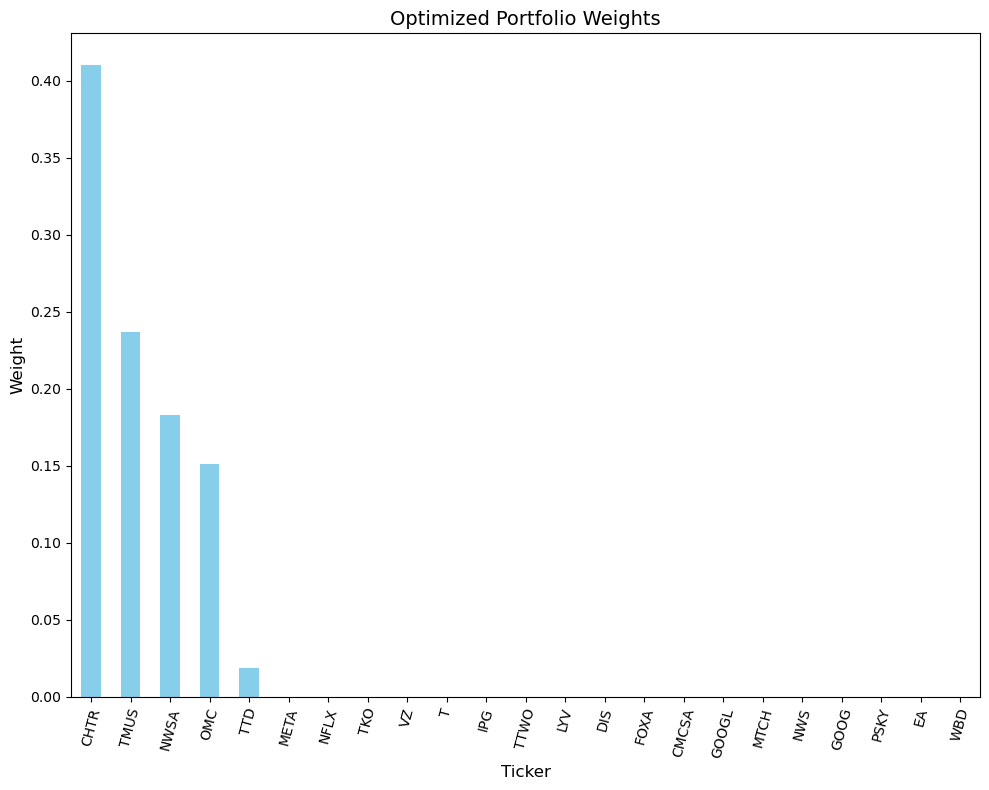

In [26]:
weights = pd.Series(result.x, index=usable)
weights_sorted = weights.sort_values(ascending=False)

plt.figure(figsize=(10, 8))

weights_sorted.plot(
    kind = 'bar',            
    color = 'skyblue'      
)

plt.title("Optimized Portfolio Weights", fontsize = 14)
plt.ylabel("Weight", fontsize = 12)
plt.xlabel("Ticker", fontsize = 12)
plt.xticks(rotation = 75)
plt.tight_layout()
plt.show()

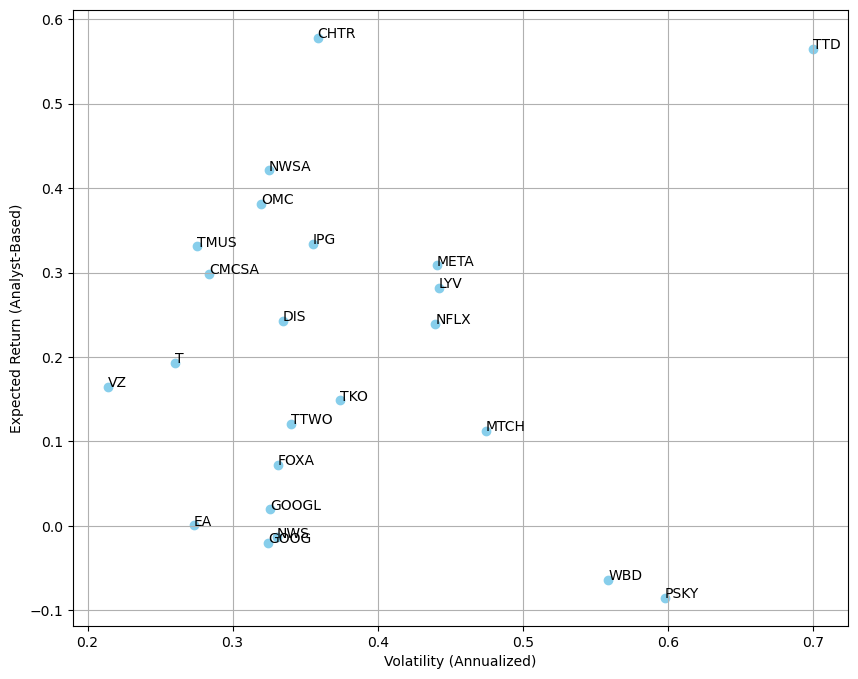

In [33]:
vols = returns.std() * np.sqrt(252)
exps = annual_returns

plt.figure(figsize=(10, 8))

# scatter plot
plt.scatter(vols, exps, color='skyblue')

# add labels
for ticker in exps.index:
    plt.annotate(ticker, (vols[ticker], exps[ticker]))

plt.xlabel("Volatility (Annualized)")
plt.ylabel("Expected Return (Analyst-Based)")
plt.grid()
plt.show()